# Experiment Cartoons

Clean matplotlib-based cartoons illustrating the different experimental conditions.


In [28]:
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path


import sys
import os

# Configure paths
ROOT = Path("..")
sys.path.insert(0, str(ROOT))
plt.style.use(os.path.join(ROOT, "plot", "mplstyle.txt"))

# Style configuration
COLORS = {
    "scatter": "#1a6e6e",  # Dark teal for scatter points
    "line": "#2d5a5a",  # Darker teal for lines
    "axis": "#4a4a4a",  # Dark gray for axes
    "label": "#2d5a5a",  # Teal for labels
    "vline": "#888888",  # Gray for vertical reference lines
    "sim": "#1a6e6e",  # Simulations color
    "obs": "#cc5500",  # Observations color (orange)
    "contam": "#cc3333",  # Red for contamination
}


def setup_cartoon_axes(ax, xlabel, ylabel):
    """Configure axes with minimal cartoon style - no ticks, no limits shown."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color(COLORS["axis"])
    ax.spines["left"].set_color(COLORS["axis"])
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(xlabel)  # , fontsize=13, color=COLORS["label"], fontweight="bold")
    ax.set_ylabel(ylabel)  # , fontsize=13, color=COLORS["label"], fontweight="bold")
    return ax

## 1. M-C Scatter

Mass-Concentration relation with low vs high intrinsic scatter. Slight negative correlation.


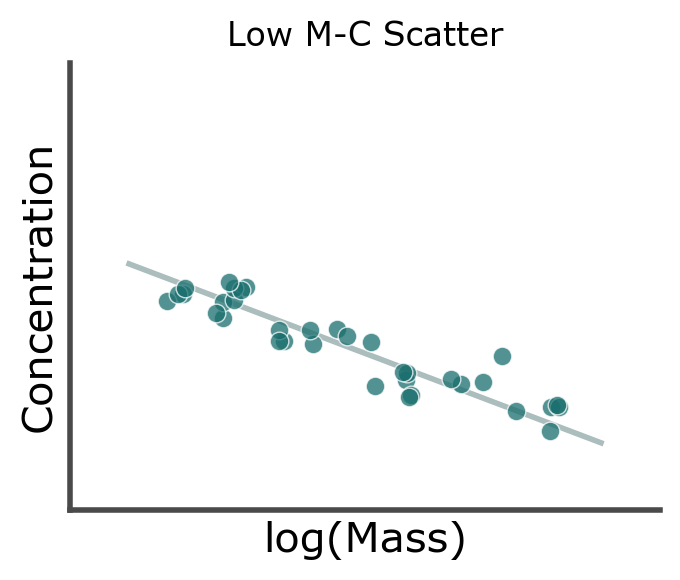

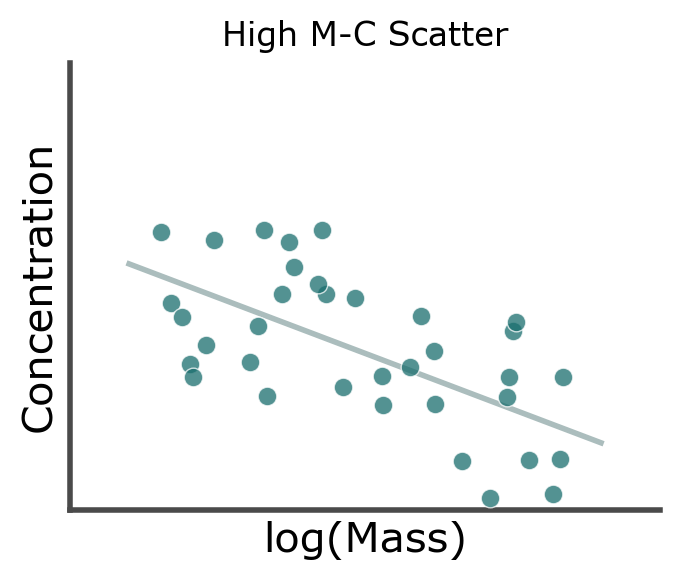

In [61]:
def plot_mc_scatter(ax, scatter_level="low", title=None):
    """Plot M-C relation cartoon with slight negative correlation."""
    np.random.seed(42 if scatter_level == "low" else 43)
    n_points = 35

    log10mass = np.random.uniform(0.15, 0.85, n_points)
    scatter_sigma = 0.04 if scatter_level == "low" else 0.12
    concentration = 0.6 - 0.5 * log10mass + np.random.normal(0, scatter_sigma, n_points)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    setup_cartoon_axes(ax, "log(Mass)", "Concentration")

    # Mean relation line
    x_line = np.linspace(0.1, 0.9, 50)
    y_line = 0.6 - 0.5 * x_line
    ax.plot(x_line, y_line, color=COLORS["line"], linewidth=2, alpha=0.4, zorder=1)

    ax.scatter(
        log10mass,
        concentration,
        c=COLORS["scatter"],
        s=45,
        alpha=0.75,
        edgecolors="white",
        linewidth=0.5,
        zorder=5,
    )

    if title:
        ax.set_title(title)  # , fontsize=11, fontweight="bold", pad=8)


# fig, axes = plt.subplots(1, 2, figsize=(7, 3))
# plot_mc_scatter(axes[0], scatter_level="low", title="Low M-C Scatter")
# plot_mc_scatter(axes[1], scatter_level="high", title="High M-C Scatter")
# plt.tight_layout()
# plt.savefig("../outputs/plots/cartoon_mc_scatter.pdf", bbox_inches="tight", dpi=150)
# plt.show()

for scatter_level in ["low", "high"]:
    fig, ax = plt.subplots(figsize=(3.5, 3))
    plot_mc_scatter(
        ax,
        scatter_level=scatter_level,
        title=f"{scatter_level.capitalize()} M-C Scatter",
    )
    plt.tight_layout()
    plt.savefig(
        f"../outputs/plots/cartoons/m_c_{scatter_level}_scatter_2.pdf"  # , bbox_inches="tight", dpi=150
    )
    plt.show()

## 2. λ-M Scatter

Richness-Mass relation with positive correlation and vertical bin lines.


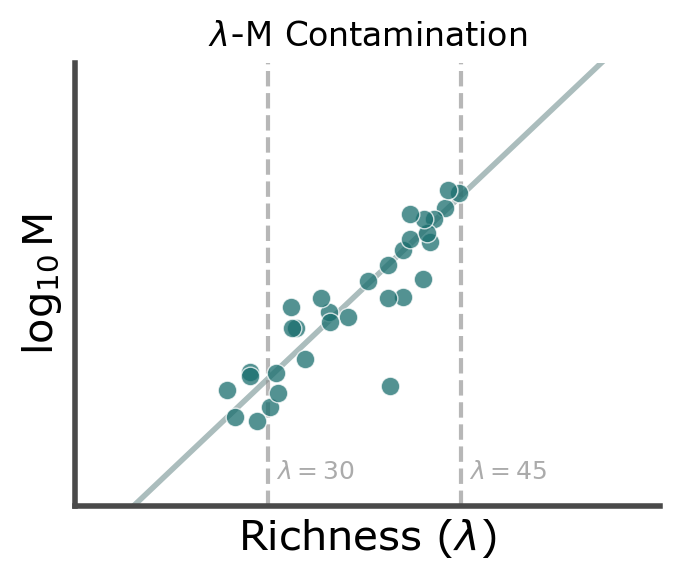

In [67]:
def plot_lambda_m_scatter(ax, scatter_level="low", title=None, show_bins=True):
    """Plot λ-M relation cartoon with positive correlation."""
    np.random.seed(44 if scatter_level == "low" else 45)
    n_points = 45

    log10mass = np.random.uniform(0.15, 0.85, n_points)
    scatter_sigma = 0.05 if scatter_level == "low" else 0.15
    richness = 0.1 + 0.8 * log10mass + np.random.normal(0, scatter_sigma, n_points)

    # richness = np.clip(richness, 0.33, 0.66)  # Ensure richness stays within [0, 1]
    # remove values from richness and log10mass where richness is outside [0.33, 0.66]
    mask = (richness >= 0.2) & (richness <= 0.66)
    richness = richness[mask]
    log10mass = log10mass[mask]

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    setup_cartoon_axes(ax, r"Richness ($\lambda$)", r"$\log_{10}$M")

    if show_bins:
        ax.axvline(
            0.33, color=COLORS["vline"], linestyle="--", linewidth=1.5, alpha=0.6
        )
        # add a label that says lambda = 30
        ax.text(
            0.41,
            0.05,
            r"$\lambda = 30$",
            color=COLORS["vline"],
            fontsize=9,
            ha="center",
            va="bottom",
            alpha=0.7,
        )
        ax.axvline(
            0.66, color=COLORS["vline"], linestyle="--", linewidth=1.5, alpha=0.6
        )
        # add a label that says lambda = 45
        ax.text(
            0.74,
            0.05,
            r"$\lambda = 45$",
            color=COLORS["vline"],
            fontsize=9,
            ha="center",
            va="bottom",
            alpha=0.7,
        )

    # Mean relation line
    x_line = np.linspace(0.1, 0.9, 50)
    y_line = (x_line - 0.1) / 0.8
    ax.plot(x_line, y_line, color=COLORS["line"], linewidth=2, alpha=0.4, zorder=1)

    ax.scatter(
        richness,
        log10mass,
        c=COLORS["scatter"],
        s=45,
        alpha=0.75,
        edgecolors="white",
        linewidth=0.5,
        zorder=5,
    )

    if title:
        ax.set_title(title)  # , fontsize=11, fontweight="bold", pad=8)


# for scatter_level in ["low", "high"]:
fig, ax = plt.subplots(figsize=(3.5, 3))
plot_lambda_m_scatter(
    ax,
    scatter_level="low",
    title=rf"$\lambda$-M Contamination",
)
plt.tight_layout()
plt.savefig(
    f"../outputs/plots/cartoons/lambda_m_contam.pdf"  # , bbox_inches="tight", dpi=150
)
plt.show()

## 3. Noise Levels

ΔΣ profile with power-law decay (linear on log-log axes).


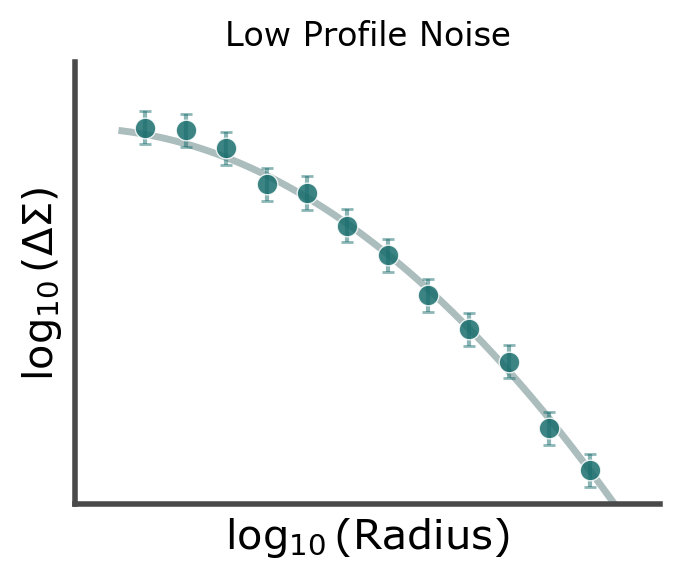

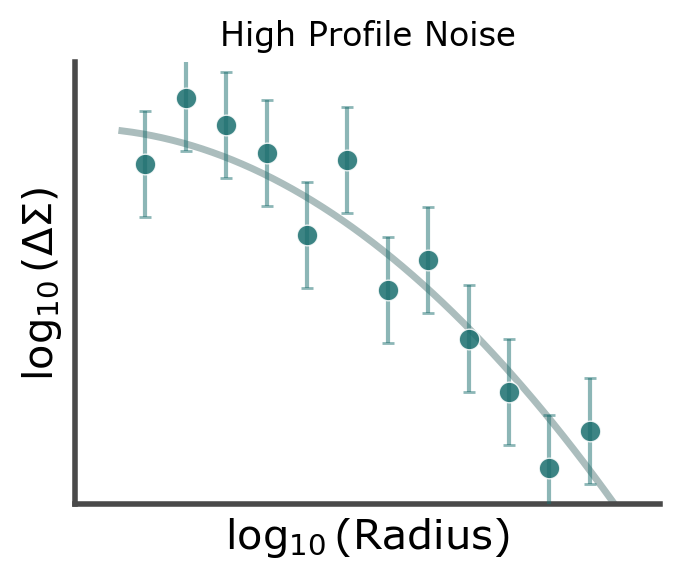

In [59]:
def plot_delta_sigma_noise(ax, noise_level="low", title=None):
    """Plot ΔΣ profile cartoon - power-law decay on log-log."""
    np.random.seed(46 if noise_level == "low" else 47)
    n_points = 12

    log_radius = np.linspace(0.12, 0.88, n_points)
    true_profile = 0.85 - log_radius**2

    noise_sigma = 0.025 if noise_level == "low" else 0.08
    observed = true_profile + np.random.normal(0, noise_sigma, n_points)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    setup_cartoon_axes(ax, r"$\log_{10}$(Radius)", r"$\log_{10}(\Sigma)$")

    # True profile line
    x_line = np.linspace(0.08, 0.92, 50)
    y_line = 0.85 - x_line**2
    ax.plot(x_line, y_line, color=COLORS["line"], linewidth=2.5, alpha=0.4, zorder=1)

    ax.errorbar(
        log_radius,
        observed,
        yerr=noise_sigma * 1.5,
        fmt="none",
        ecolor=COLORS["scatter"],
        alpha=0.5,
        capsize=2,
        zorder=4,
    )
    ax.scatter(
        log_radius,
        observed,
        c=COLORS["scatter"],
        s=55,
        alpha=0.85,
        edgecolors="white",
        linewidth=0.5,
        zorder=5,
    )

    if title:
        ax.set_title(title)  # , fontsize=11, fontweight="bold", pad=8)


# fig, axes = plt.subplots(1, 2, figsize=(7, 3))
# plot_delta_sigma_noise(axes[0], noise_level="low", title="Low Noise")
# plot_delta_sigma_noise(axes[1], noise_level="high", title="High Noise")
# plt.tight_layout()
# plt.savefig("../outputs/plots/cartoon_noise_levels.pdf", bbox_inches="tight", dpi=150)
# plt.show()

for noise_level in ["low", "high"]:
    fig, ax = plt.subplots(figsize=(3.5, 3))
    plot_delta_sigma_noise(
        ax,
        noise_level=noise_level,
        title=rf"{noise_level.capitalize()} Profile Noise",
    )
    plt.tight_layout()
    plt.savefig(
        f"../outputs/plots/cartoons/profile_noise_{noise_level}.pdf"  # , bbox_inches="tight", dpi=150
    )
    plt.show()

## 4. Noise Mismatch

Simulations vs observations with different noise levels.


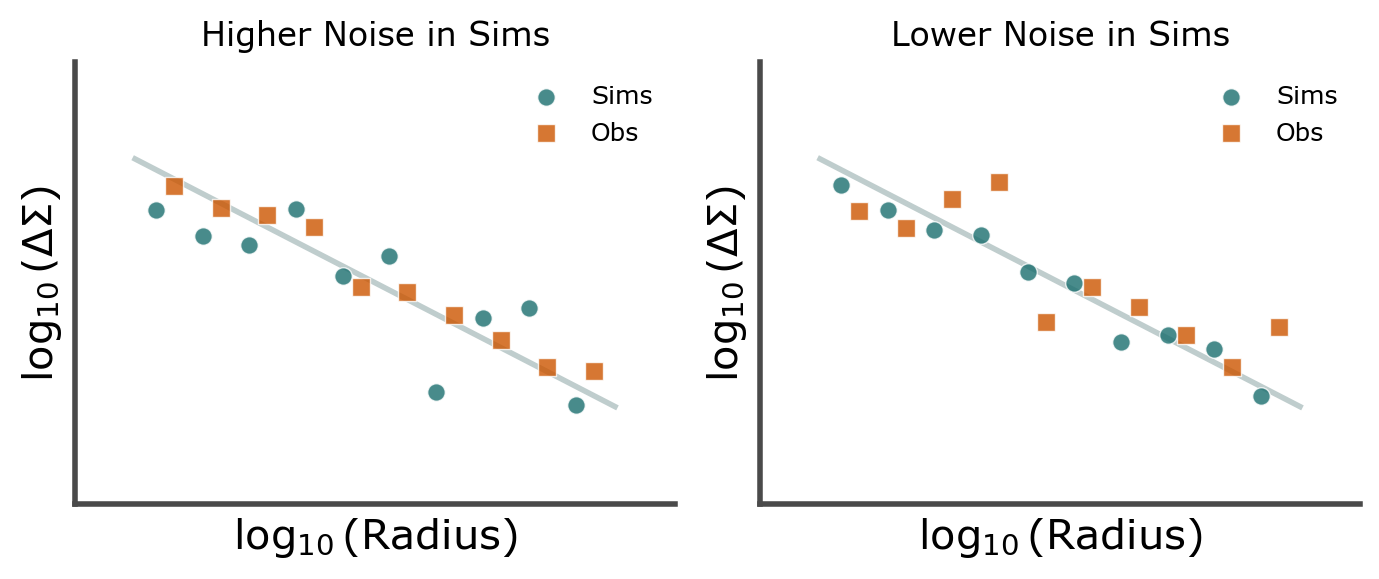

In [50]:
def plot_noise_mismatch(ax, sim_noise, obs_noise, title=None):
    """Plot overlaid ΔΣ profiles showing sim vs obs noise mismatch."""
    np.random.seed(48)
    n_points = 10

    log_radius = np.linspace(0.15, 0.85, n_points)
    true_profile = 0.85 - 0.7 * log_radius

    sim_sigma = 0.025 if sim_noise == "low" else 0.08
    obs_sigma = 0.025 if obs_noise == "low" else 0.08

    sim_data = true_profile + np.random.normal(0, sim_sigma, n_points)
    np.random.seed(49)
    obs_data = true_profile + np.random.normal(0, obs_sigma, n_points)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    setup_cartoon_axes(ax, "$\log_{10}$(Radius)", r"$\log_{10}(\Delta\Sigma$)")

    x_line = np.linspace(0.1, 0.9, 50)
    y_line = 0.85 - 0.7 * x_line
    ax.plot(x_line, y_line, color=COLORS["line"], linewidth=2, alpha=0.3, zorder=1)

    ax.scatter(
        log_radius - 0.015,
        sim_data,
        c=COLORS["sim"],
        s=40,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
        label="Sims",
        marker="o",
        zorder=5,
    )
    ax.scatter(
        log_radius + 0.015,
        obs_data,
        c=COLORS["obs"],
        s=40,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
        label="Obs",
        marker="s",
        zorder=5,
    )

    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
    if title:
        ax.set_title(title)  # , fontsize=11, fontweight="bold", pad=8)


fig, axes = plt.subplots(1, 2, figsize=(7, 3))
plot_noise_mismatch(
    axes[0], sim_noise="high", obs_noise="low", title="Higher Noise in Sims"
)
plot_noise_mismatch(
    axes[1], sim_noise="low", obs_noise="high", title="Lower Noise in Sims"
)
plt.tight_layout()
plt.savefig("../outputs/plots/cartoon_noise_mismatch.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 5. λ-M Scatter Mismatch

Simulations vs observations with different scatter levels.


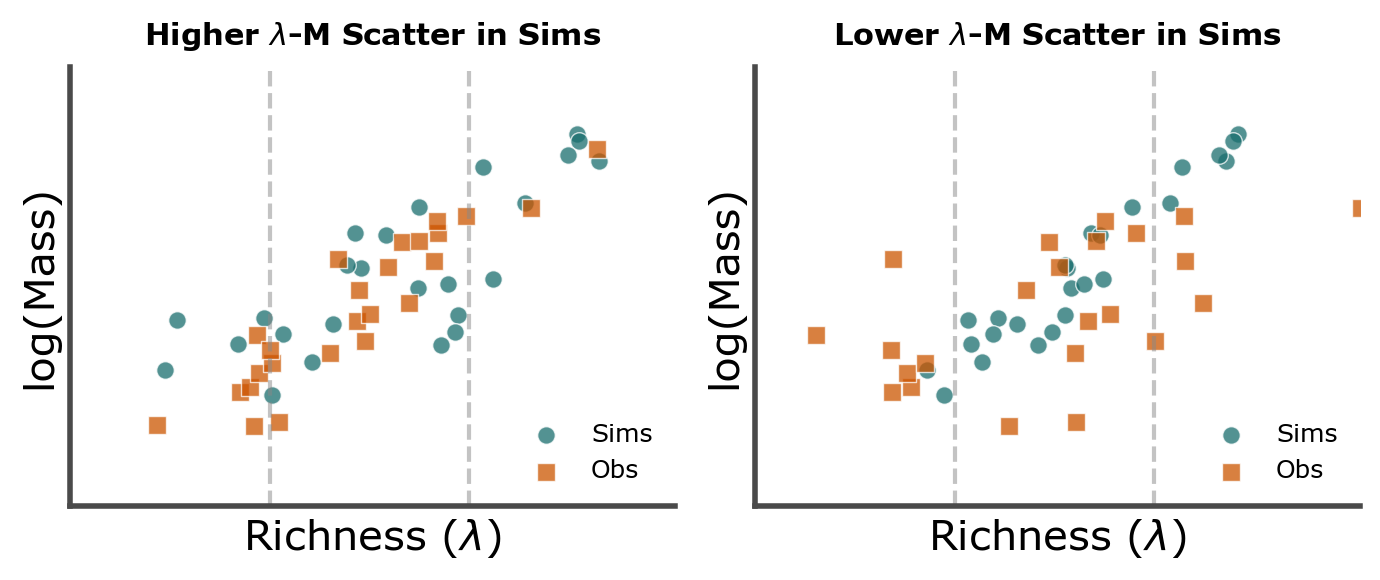

In [33]:
def plot_scatter_mismatch(ax, sim_scatter, obs_scatter, title=None):
    """Plot overlaid λ-M relations showing sim vs obs scatter mismatch."""
    np.random.seed(50)
    n_points = 25

    log10mass_sim = np.random.uniform(0.15, 0.85, n_points)
    np.random.seed(51)
    log10mass_obs = np.random.uniform(0.15, 0.85, n_points)

    sim_sigma = 0.05 if sim_scatter == "low" else 0.15
    obs_sigma = 0.05 if obs_scatter == "low" else 0.15

    np.random.seed(52)
    richness_sim = 0.1 + 0.8 * log10mass_sim + np.random.normal(0, sim_sigma, n_points)
    np.random.seed(53)
    richness_obs = 0.1 + 0.8 * log10mass_obs + np.random.normal(0, obs_sigma, n_points)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    setup_cartoon_axes(ax, r"Richness ($\lambda$)", "log(Mass)")

    ax.axvline(0.33, color=COLORS["vline"], linestyle="--", linewidth=1.5, alpha=0.5)
    ax.axvline(0.66, color=COLORS["vline"], linestyle="--", linewidth=1.5, alpha=0.5)

    ax.scatter(
        richness_sim,
        log10mass_sim,
        c=COLORS["sim"],
        s=40,
        alpha=0.75,
        edgecolors="white",
        linewidth=0.5,
        label="Sims",
        marker="o",
    )
    ax.scatter(
        richness_obs,
        log10mass_obs,
        c=COLORS["obs"],
        s=40,
        alpha=0.75,
        edgecolors="white",
        linewidth=0.5,
        label="Obs",
        marker="s",
    )

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)


fig, axes = plt.subplots(1, 2, figsize=(7, 3))
plot_scatter_mismatch(
    axes[0],
    sim_scatter="high",
    obs_scatter="low",
    title=r"Higher $\lambda$-M Scatter in Sims",
)
plot_scatter_mismatch(
    axes[1],
    sim_scatter="low",
    obs_scatter="high",
    title=r"Lower $\lambda$-M Scatter in Sims",
)
plt.tight_layout()
plt.savefig(
    "../outputs/plots/cartoon_scatter_mismatch.pdf", bbox_inches="tight", dpi=150
)
plt.show()

## 6. Bin Contamination

Clusters scattering into adjacent richness bins.


/var/folders/7n/ym9ck7gn31z2k4rkws3j2slr0000gn/T/ipykernel_43716/640579323.py:41: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


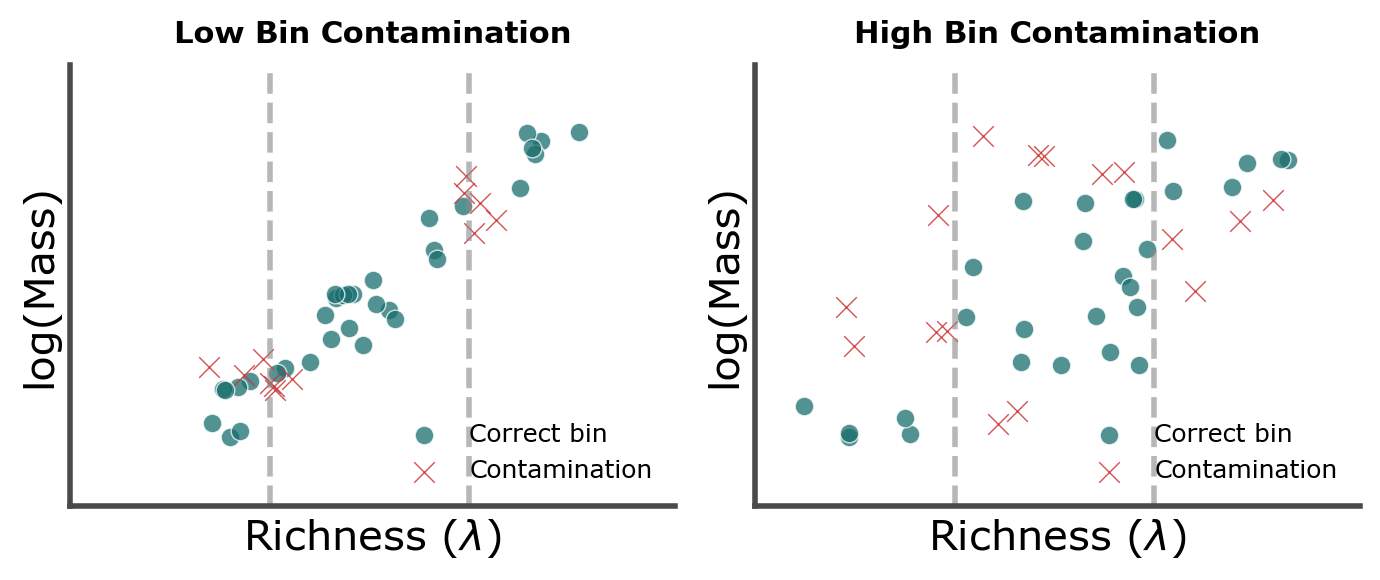

In [34]:
def plot_bin_contamination(ax, contamination_level="low", title=None):
    """Plot λ-M showing contamination between richness bins."""
    np.random.seed(54 if contamination_level == "low" else 55)
    n_points = 45

    log10mass = np.random.uniform(0.15, 0.85, n_points)
    true_richness = 0.1 + 0.8 * log10mass

    scatter_sigma = 0.05 if contamination_level == "low" else 0.18
    observed_richness = true_richness + np.random.normal(0, scatter_sigma, n_points)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    setup_cartoon_axes(ax, r"Richness ($\lambda$)", "log(Mass)")

    for edge in [0.33, 0.66]:
        ax.axvline(edge, color=COLORS["vline"], linestyle="--", linewidth=2, alpha=0.6)

    def get_bin(r):
        if r < 0.33:
            return 0
        elif r < 0.66:
            return 1
        else:
            return 2

    true_bins = np.array([get_bin(r) for r in true_richness])
    obs_bins = np.array([get_bin(r) for r in observed_richness])
    same_bin = true_bins == obs_bins

    ax.scatter(
        observed_richness[same_bin],
        log10mass[same_bin],
        c=COLORS["scatter"],
        s=45,
        alpha=0.75,
        edgecolors="white",
        linewidth=0.5,
        label="Correct bin",
    )
    ax.scatter(
        observed_richness[~same_bin],
        log10mass[~same_bin],
        c=COLORS["contam"],
        s=55,
        alpha=0.85,
        edgecolors="white",
        linewidth=0.5,
        label="Contamination",
        marker="x",
    )

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)


fig, axes = plt.subplots(1, 2, figsize=(7, 3))
plot_bin_contamination(
    axes[0], contamination_level="low", title="Low Bin Contamination"
)
plot_bin_contamination(
    axes[1], contamination_level="high", title="High Bin Contamination"
)
plt.tight_layout()
plt.savefig(
    "../outputs/plots/cartoon_bin_contamination.pdf", bbox_inches="tight", dpi=150
)
plt.show()

## 7. Combined Summary Figures


/var/folders/7n/ym9ck7gn31z2k4rkws3j2slr0000gn/T/ipykernel_43716/640579323.py:41: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


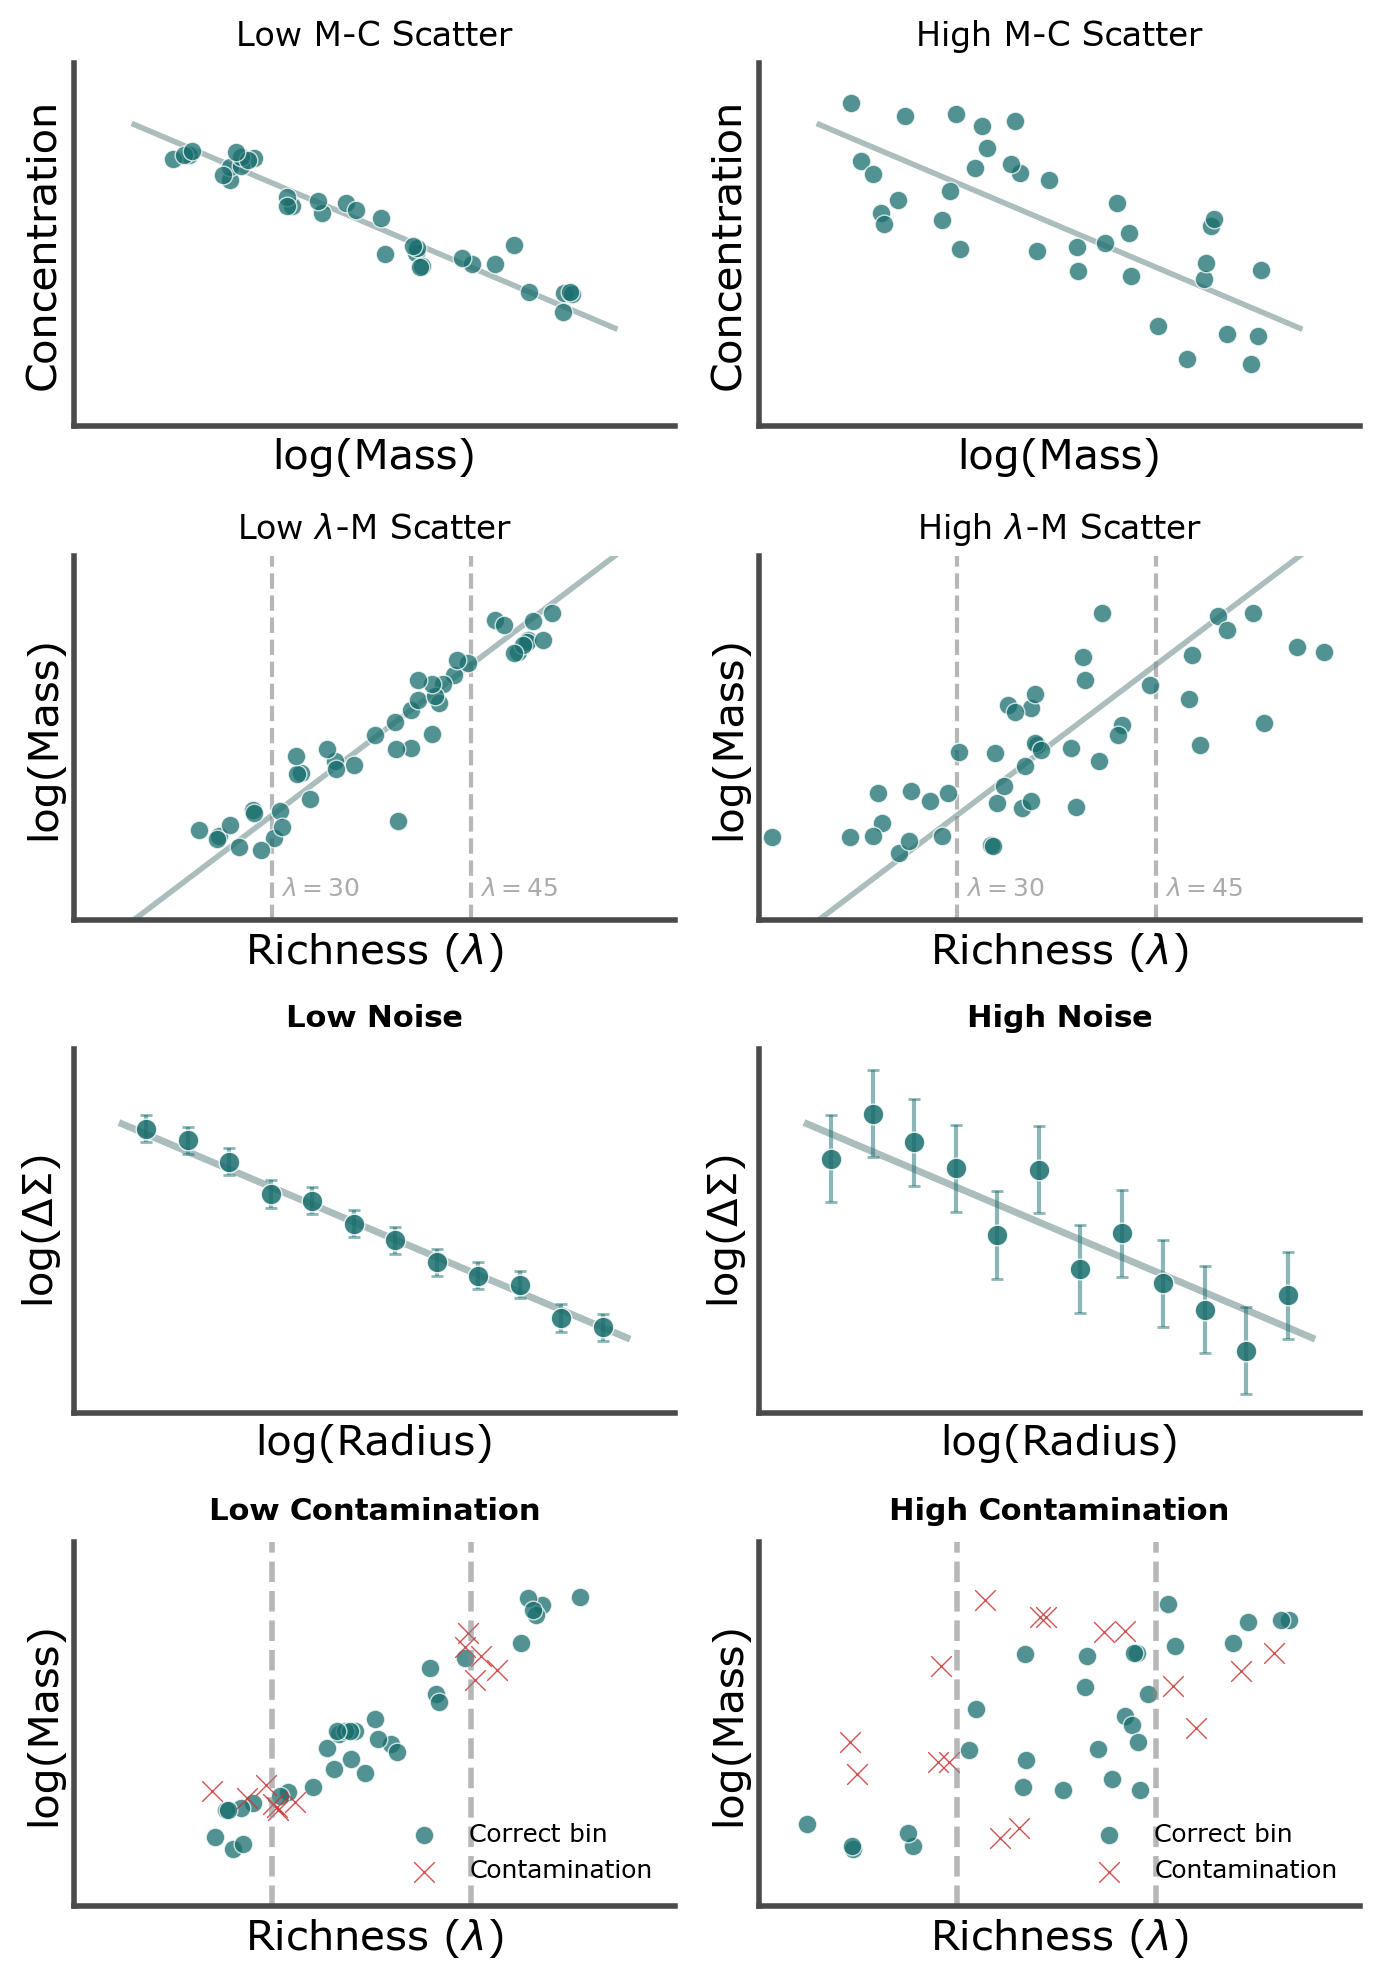

In [35]:
# All basic experiments
fig, axes = plt.subplots(4, 2, figsize=(7, 10))

plot_mc_scatter(axes[0, 0], scatter_level="low", title="Low M-C Scatter")
plot_mc_scatter(axes[0, 1], scatter_level="high", title="High M-C Scatter")

plot_lambda_m_scatter(axes[1, 0], scatter_level="low", title=r"Low $\lambda$-M Scatter")
plot_lambda_m_scatter(
    axes[1, 1], scatter_level="high", title=r"High $\lambda$-M Scatter"
)

plot_delta_sigma_noise(axes[2, 0], noise_level="low", title="Low Noise")
plot_delta_sigma_noise(axes[2, 1], noise_level="high", title="High Noise")

plot_bin_contamination(axes[3, 0], contamination_level="low", title="Low Contamination")
plot_bin_contamination(
    axes[3, 1], contamination_level="high", title="High Contamination"
)

plt.tight_layout()
plt.savefig(
    "../outputs/plots/cartoon_all_experiments.pdf", bbox_inches="tight", dpi=150
)
plt.show()

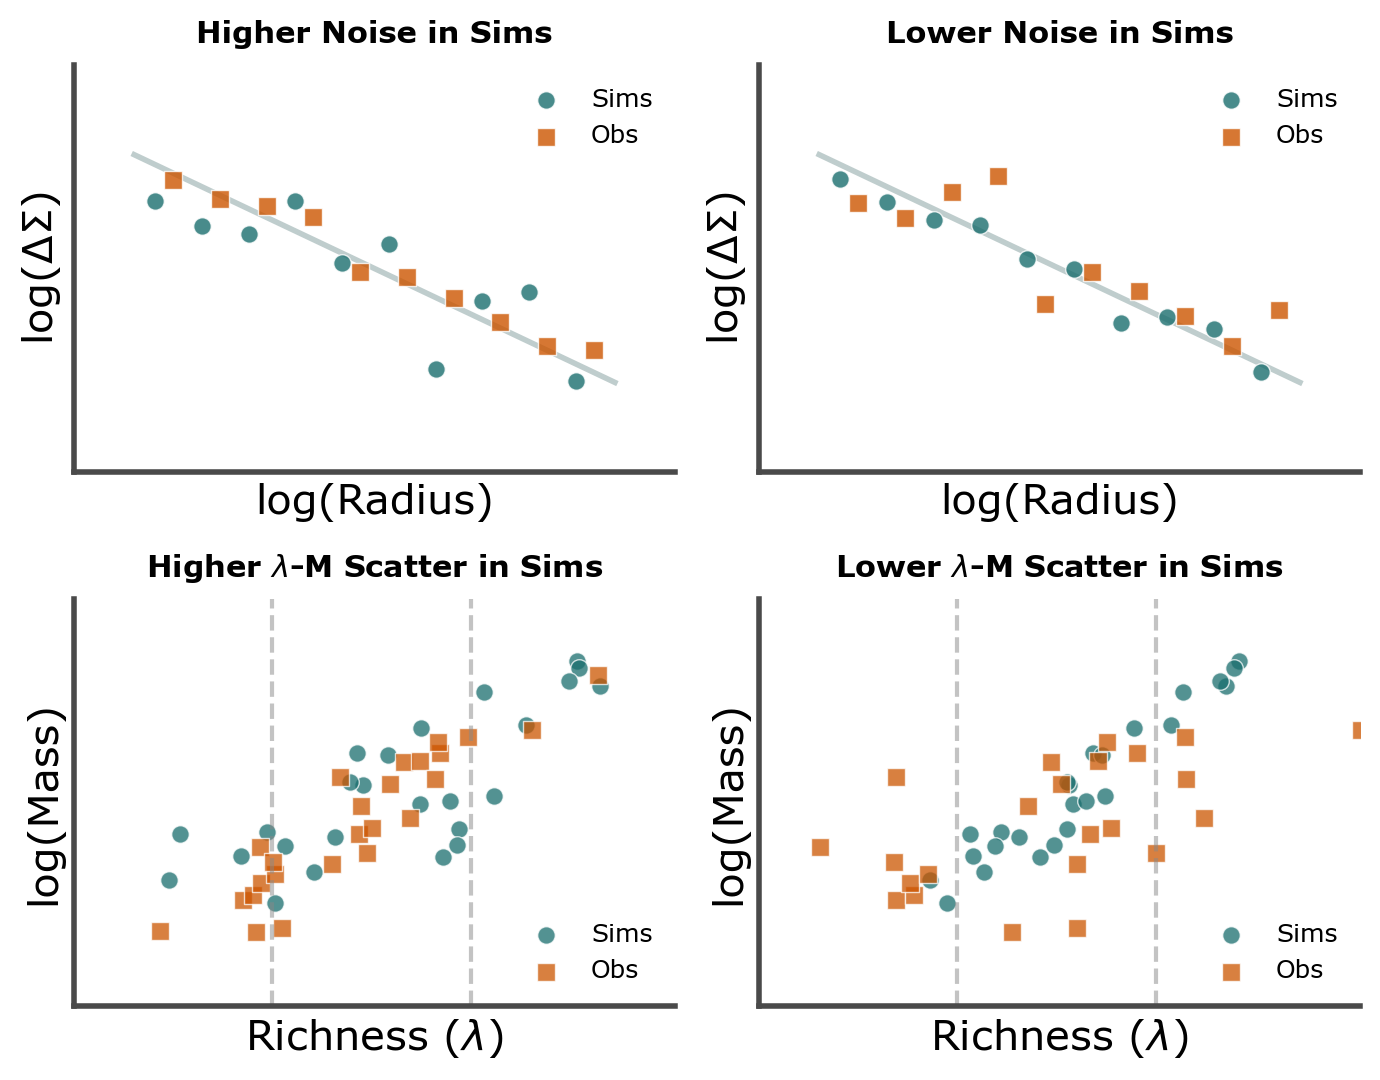

In [36]:
# Mismatch experiments
fig, axes = plt.subplots(2, 2, figsize=(7, 5.5))

plot_noise_mismatch(
    axes[0, 0], sim_noise="high", obs_noise="low", title="Higher Noise in Sims"
)
plot_noise_mismatch(
    axes[0, 1], sim_noise="low", obs_noise="high", title="Lower Noise in Sims"
)

plot_scatter_mismatch(
    axes[1, 0],
    sim_scatter="high",
    obs_scatter="low",
    title=r"Higher $\lambda$-M Scatter in Sims",
)
plot_scatter_mismatch(
    axes[1, 1],
    sim_scatter="low",
    obs_scatter="high",
    title=r"Lower $\lambda$-M Scatter in Sims",
)

plt.tight_layout()
plt.savefig(
    "../outputs/plots/cartoon_mismatch_experiments.pdf", bbox_inches="tight", dpi=150
)
plt.show()